# Simulation of satellite-detected hailstorms in the Australian tropics

In the Australian tropics, satellites and proxies often see indications of hail or hail-prone conditions, yet the actual occurrance of hail at the surface is uncertain given sparse observations. Here I use WRF to simulate hailstorms where satellite retrievals detected the presence of hail (aloft). The simulations are run using three microphysics schemes.

In [1]:
%cd git/kimberley_hail

/home/561/tr2908/git/kimberley_hail


In [2]:
import sys
sys.path.append('../xarray_parcel/')

import dask
import xarray
import numpy as np
import pandas as pd
import seaborn as sns
import cartopy.crs as ccrs
from importlib import reload
import modules.nth_hail as nh
import matplotlib.pyplot as plt
import modules.wrf_metadata as wm
from dask.distributed import Client
import modules.parcel_functions as parcel

In [3]:
client = Client(n_workers=16)

## Settings

In [4]:
BC2019_file = 'data/GMI_BC2019_20_hailcases_AUST.txt'                # Data file containing Bang & Cecil 2019 hail detections.
sims_dir = '/g/data/w42/tr2908/kimberley_hail/WRF_v4.4/simulations/' # Directory where simulations are held.
wrf_dir = '/g/data/w42/tr2908/kimberley_hail/WRF_v4.4/template/'     # Directory with compiled WRF and basic namelist files.
adiabat_lookups = '/g/data/w42/tr2908/aus400_hail/'                  # Parcel adiabat lookup dir.

## Setup

In [5]:
plt.show()                                                       # Start the plotting engine.
plt.rcParams['font.size'] = 14                                   # Font size for plots.
plt.rcParams['axes.formatter.useoffset'] = False                 # Don't use offsets in plots.
_ = dask.config.set({'array.slicing.split_large_chunks': False}) # Allow for large dask chunks.

## Event selection

Events to simulate are selected from data provided by Sarah Bang, with locations and times of satellite-detected hailstorms. We look for "good" detections in northern Australia with a hail probability over 50%.

In [6]:
hail_detections = pd.read_csv(BC2019_file, sep='\s+')
hail_detections = hail_detections[hail_detections.LAT > -19]           # Select only northern-Australia detections.
hail_detections = hail_detections[hail_detections.FLAG == 1]           # Select detections that were not flagged for snow/surface features.
hail_detections = hail_detections[hail_detections.P_hail_BC2019 > 0.5] # Select only detections with Bang & Cecil 2019 hail probability over 50%.
hail_detections = hail_detections.reset_index(drop=True)
print(f'The dataset contains {len(hail_detections)} hail detections.')

The dataset contains 44 hail detections.


We simulate the hour before the event, the hour of the event and the hour after the event, so each event has 3 hours of simulation time. The start time is shifted back 12 hours to give a 12 hour spin-up time. Total simulation time is then 15 hours per event.

In [7]:
hail_detections['event_time'] = pd.to_datetime((hail_detections.YEAR.astype(str) + '-' + 
                                                hail_detections.MONTH.astype(str) + '-' + 
                                                hail_detections.DAY.astype(str) + ' ' +
                                                hail_detections.HOUR.astype(str) + ':' + 
                                                hail_detections.MIN.astype(str)))
hail_detections['start_time'] = (hail_detections.event_time - np.timedelta64(13, 'h')).dt.floor('H')
hail_detections['end_time'] = (hail_detections.event_time + np.timedelta64(1, 'h')).dt.ceil('H')
hail_detections['start_time'] = hail_detections.start_time.dt.strftime('%Y-%m-%d_%H:%M:00')
hail_detections['end_time'] = hail_detections.end_time.dt.strftime('%Y-%m-%d_%H:%M:00')

Here is a map showing the locations of the hail detections we study here as red dots.

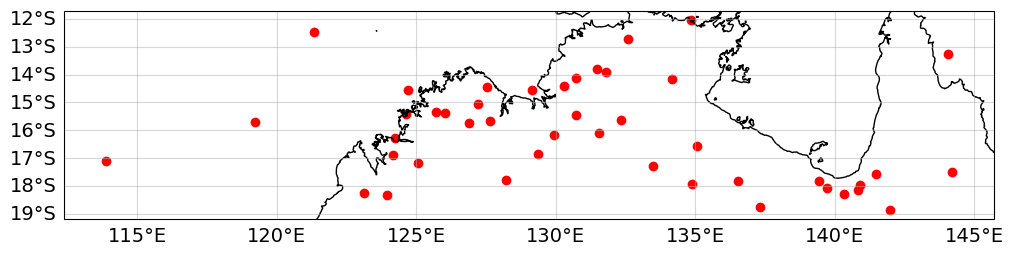

In [8]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12,8))
ax.scatter(hail_detections.LON, hail_detections.LAT, transform=ccrs.PlateCarree(), color='red')
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, alpha=0.5)
gl.top_labels = gl.right_labels = False
ax.coastlines()
plt.show()

## Simulation computation

The following code can be run to create a directory for each simulation and set up all the namelist files to use the correct locations and times.

In [9]:
#for i, row in hail_detections.iterrows():
#    nh.set_up_WRF(lat=row.LAT, lon=row.LON, year=row.YEAR, month=row.MONTH, day=row.DAY, hour=row.HOUR, minute=row.MIN, 
#                  start_time=row.start_time, end_time=row.end_time, wrf_dir=wrf_dir, sims_dir=sims_dir)

To run WPS for each simulation:

```
cd /g/data/w42/tr2908/kimberley_hail/WRF_v4.4/simulations/
for i in lat*; do cd $i/WPS; echo `pwd`; qsub ~/git/kimberley_hail/scripts/run_WPS.sh; cd ../../; done
```

Once WPS has run on all, then run WRF:

```
cd /g/data/w42/tr2908/kimberley_hail/WRF_v4.4/simulations/
for i in lat*/WRF/*; do cd $i; echo `pwd`; qsub ~/git/kimberley_hail/scripts/run_WRF.sh; cd ../../../; done
```

After WRF has finished, then run two scripts to calculate basic properties for all outputs - **note if doing again, make only run for last three output files to avoid spinup**:

```
cd /g/data/w42/tr2908/kimberley_hail/WRF_v4.4/simulations/
for i in lat*/WRF/*; do cd $i; echo `pwd`; qsub ~/git/kimberley_hail/scripts/process_WRF_basic.sh; cd ../../../; done
```

Run a script to calculate convective properties:

```
cd /g/data/w42/tr2908/kimberley_hail/WRF_v4.4/simulations/
for i in lat*/WRF/*; do cd $i; echo `pwd`; qsub ~/git/kimberley_hail/scripts/process_WRF_conv.sh; cd ../../../; done
```

And finally run a script to interpolate vertical data to pressure levels:

```
cd /g/data/w42/tr2908/kimberley_hail/WRF_v4.4/simulations/
for i in lat*/WRF/*; do cd $i; echo `pwd`; qsub ~/git/kimberley_hail/scripts/interpolate_to_hPa_levels.sh; cd ../../../; done
```

To remove the "missing_values" attribute that caused xarray warnings from `basic_*.nc files`, I ran:

```
cd /g/data/w42/tr2908/kimberley_hail/WRF_v4.4/simulations/
for i in lat*/WRF/*/basic*.nc; do echo $i; ncatted -O -a missing_value,pressure,d,, $i; done
```

## Simulation details

Here are details of the simulation setup, which is simply moved and placed over each hail detection. Three different microphysics schemes are used (NSSL, P3-3M, and MY2).

In [10]:
row = hail_detections.iloc[1,]
dr = nh.sim_directory(lat=row.LAT, lon=row.LON, year=row.YEAR, month=row.MONTH, day=row.DAY, hour=row.HOUR, minute=row.MIN, sims_dir=sims_dir)
wm.analyse_wrfinput(f'{dr}/WRF/NSSL/wrfinput_d03')

0.3.0
Sea surface temperature (SST):			0.0 K
Surface skin temperature (TSK):			298.65466 K
Soil temperature at lower boundary (TMN):	299.27625 K
Horizontal grid spacing (DX):			1000.0 m
Horizontal (S-N) grid spacing (DY):		1000.0 m
Horizontal (W-E) domain size:			120 mass points
Horizontal (S-N) domain size:			120 mass points
Vertical domain size:				79 mass points
Maximum geopotential height (model-top):	20577.9 m
Min, mean, max vertical dist. between mass pts:	53.1, 260.1, 353.8 m
Model-top pressure:				5000.0 Pa
Physics schemes:
	Microphysics:				17 (NSSL 2-moment)
	Radiation (longwave):			4 (RRTMG)
	Radiation (shortwave):			4 (RRTMG)
	Surface layer:				1 (Revised MM5 Monin-Obukhov)
	Land-surface:				4 (Noah-MP)
	PBL:					1 (YSU)
	Cumulus:				0 (No cumulus parameterisation)
Turbulence options:
	Diffusion (diff_opt):			2 (Full diffusion)
	Eddy coefficient (km_opt):		4 (2D (horiz) Smagorinsky)


## Read data

In [11]:
%%time
dat = nh.open_kimberley_data(hail_detections=hail_detections, sims_dir=sims_dir)

CPU times: user 49.8 s, sys: 5.01 s, total: 54.8 s
Wall time: 2min 16s


AFWA calculations were enabled while WRF was compiled in `dm+sm` mode, and I have since found out that AFWA's coding is not thread safe so will overwrite values improperly in `dm+sm` mode. I did a trial for one event and found that all other fields were identical when AFWA was turned off, and a forum post to the WRF forum also confirmed that other variables would be unaffected. The WRF output variables possible affected are:

```
'AFWA_CAPE', 'AFWA_CAPE_MU', 'AFWA_CIN', 'AFWA_CIN_MU', 'AFWA_HAIL', 'AFWA_LIDX', 
'AFWA_LLWS', 'AFWA_MSLP', 'AFWA_PLFC', 'AFWA_PWAT', 'AFWA_TORNADO', 'AFWA_TOTPRECIP', 
'AFWA_ZLFC', 'GRPL_FLX_MAX', 'TCOLI_MAX', 'WSPD10MAX', 'W_UP_MAX', 'W_DN_MAX'
```

These variables are possibly-incorrect and should not be used in this work.

I remove any HAILCAST diameters over 200 mm since 20 cm seems like a reasonable upper limit for hail.

In [12]:
print(f'Removing {np.round(np.mean(dat.hailcast_diam_max > 200).values * 100, 4)}% of points for hailcast max diam > 200 mm (20 cm).')
dat = dat.where(dat.hailcast_diam_max <= 200)

Removing 0.0006% of points for hailcast max diam > 200 mm (20 cm).


Stack events and microphysics options so all can be considered separately.

In [13]:
dat = dat.stack({'event_scheme': ['event', 'mp_scheme']})

Include a flag for hail/no hail simulations.

In [14]:
dat['event_includes_hail'] = (dat.hailcast_diam_max.max(['timestep', 'south_north', 'west_east']) > 0).load()
dat['event_latitude'] = dat.latitude.mean(['timestep', 'south_north', 'west_east']).load()
dat['event_longitude'] = dat.longitude.mean(['timestep', 'south_north', 'west_east']).load()

## Hail detections in simulations

Which events and microphysics options produced hail?

In [15]:
num_events = dat.event_scheme.size
hail_events = dat.event_includes_hail.sum().values
nohail_events = num_events - hail_events

print(f'{hail_events}/{num_events}\t({np.round(hail_events/num_events*100,1)}%) of the simulations contained hail.')
print(f'{nohail_events}/{num_events}\t({np.round(nohail_events/num_events*100,1)}%) of the simulations contained no hail.')

109/132	(82.6%) of the simulations contained hail.
23/132	(17.4%) of the simulations contained no hail.


The locations of the hail/no hail simulations show no particular pattern.

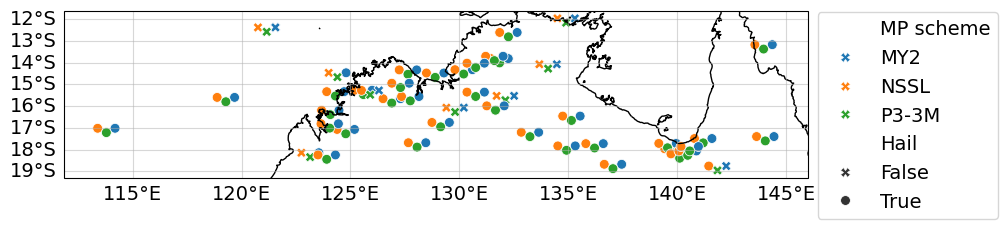

In [16]:
nh.plot_hail_simulations(dat=dat)

In [25]:
profs = dat.mean(['south_north', 'west_east']).groupby('event_includes_hail').mean().load()

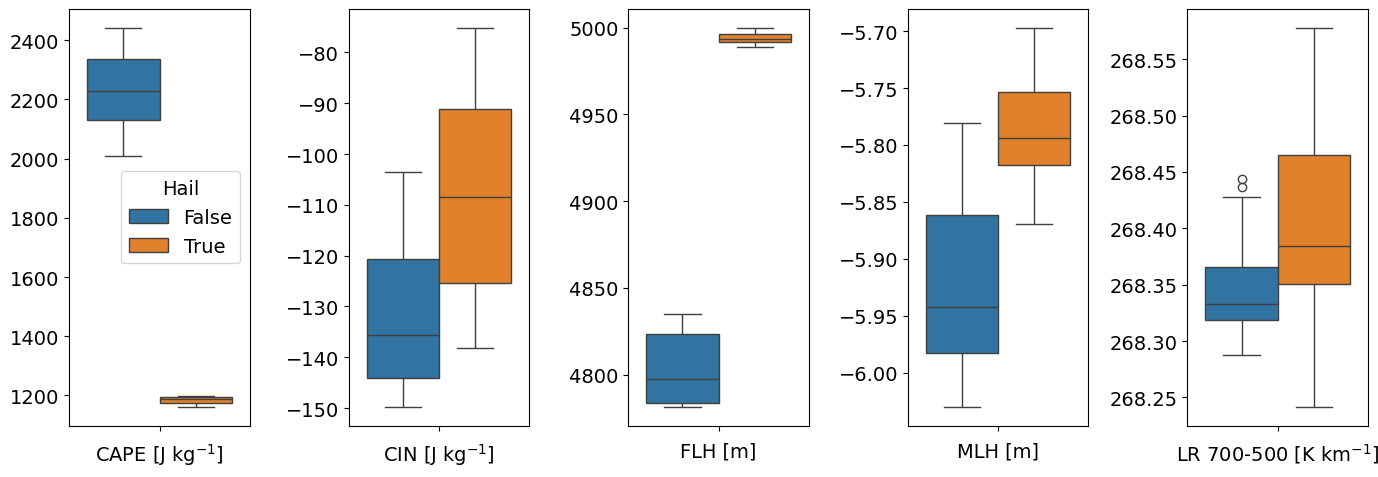

In [95]:
vars = ['mixed_100_cape', 'mixed_100_cin', 'freezing_level', 'lapse_rate_700_500', 'temp_500']
var_names = ['CAPE [J kg$^{-1}$]', 'CIN [J kg$^{-1}$]', 'FLH [m]', 'MLH [m]', 'LR 700-500 [K km$^{-1}$]', 'T500 [K]']
conv = profs[vars].to_dataframe().reset_index().rename(columns={'event_includes_hail': 'Hail'})
figsize = (14,5)
fig, axs = plt.subplots(ncols=len(vars), figsize=figsize)
for i, v in enumerate(vars):
    sns.boxplot(data=conv, y=v, hue='Hail', ax=axs[i], legend=i==0)
    axs[i].set_xlabel(var_names[i])
    axs[i].set_ylabel('')
plt.tight_layout()

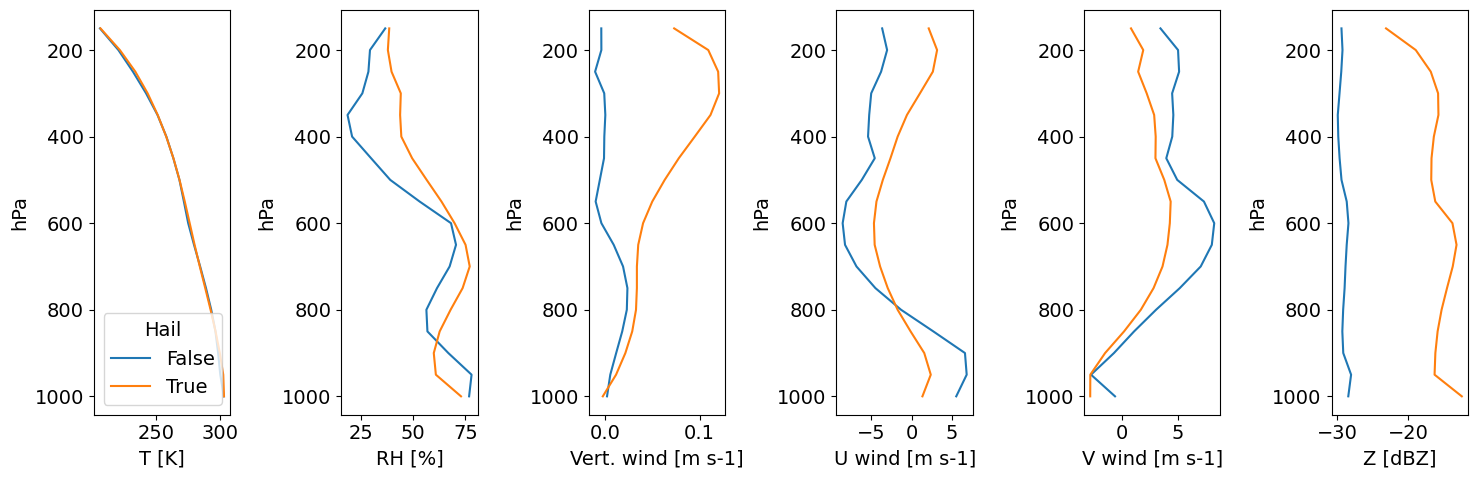

In [123]:
vars = ['temperature_at_p', 'rh_at_p', 'w_at_p', 'u_at_p', 'v_at_p', 'dbz_at_p']
var_names = ['T [K]', 'RH [%]', 'Vert. wind [m s-1]', 'U wind [m s-1]', 'V wind [m s-1]', 'Z [dBZ]']
conv = profs[vars].mean('timestep').to_dataframe().reset_index().rename(columns={'event_includes_hail': 'Hail'})
figsize = (15,5)
fig, axs = plt.subplots(ncols=len(vars), figsize=figsize)
for i, v in enumerate(vars):
    sns.lineplot(data=conv, y='pressure_level', x=v, hue='Hail', ax=axs[i], legend=i==0, sort=False)
    axs[i].set_xlabel(var_names[i])
    axs[i].set_ylabel('hPa')
    axs[i].invert_yaxis()
plt.tight_layout()

Ideas:
- In [this paper](https://www.sciencedirect.com/science/article/pii/S0169809522001296) HAILCAST was tested in Croatia with various schemes; they also ran at 1 km and said they found false alarms from HAILCAST, which they related to the updraft threshold for when HAILCAST is run. HAILCAST was designed for 3km runs and uses a 10 ms-1 updraft threshold; at 1km they used 18 ms-1 as an updated threshold. 
- In [Johnson MWR 2019](https://doi.org/10.1175/MWR-D-18-0398.1) different microphysics schemes are tested for idealised and real hail cases. The original P3 scheme does not perform so well, which is why the P3-3M scheme (used here) was developed.